# <center> 📈 **Stock Price Prediction Using Time Series Forecasting** <center>

## 🧠 Project Overview

Time Series Forecasting plays a vital role in predicting key financial indicators such as opening stock prices, closing prices, and volume of stocks traded. In today’s data-driven world, businesses and investors rely heavily on these forecasts to make informed decisions.

In this case study, we analyze and forecast Apple Inc.’s stock data sourced from the NASDAQ stock exchange, covering a time period from 2018 to 2019. Our focus is on understanding the temporal patterns in the data and applying machine learning methods to predict future stock volume using Facebook Prophet, a powerful and automated forecasting tool.

We preprocess the data, perform exploratory data analysis, and build a Prophet-based time series forecasting model. We then use this model to predict stock behavior and visualize key patterns such as trend and seasonality.

###### The following things will be covered in this case study:
###### • Exploratory Data Analysis (EDA)
###### • Time Series Preprocessing and Feature Engineering
###### • Business Day Handling with U.S. Holiday Calendars
###### • Seasonal Decomposition and Visualization
###### • Forecasting with Facebook Prophet
###### • Prediction Visualization and Component Analysis

## 📝 Problem Statement 

Forecasting stock prices using time series methods. We use Apple's stock data to demonstrate preprocessing, visualization, and prediction using Facebook Prophet.

## 📦 Importing Necessary Libraries

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from pandas import Series
from numpy import log

## 📊 Data Loading and Preview

In [9]:
# Load dataset 
df = pd.read_csv('datasets_302666_618181_AAPL.csv')

In [10]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,8/15/2018,209.220001,210.740005,208.330002,210.240005,207.027420,28807600
1,8/16/2018,211.750000,213.809998,211.470001,213.320007,210.060333,28500400
2,8/17/2018,213.440002,217.949997,213.160004,217.580002,214.255234,35427000
3,8/20/2018,218.100006,219.179993,215.110001,215.460007,212.167633,30287700
4,8/21/2018,216.800003,217.190002,214.029999,215.039993,211.754028,26159800


In [11]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
246,8/8/2019,200.199997,203.529999,199.389999,203.429993,202.659988,27009500
247,8/9/2019,201.300003,202.759995,199.289993,200.990005,200.990005,24619700
248,8/12/2019,199.619995,202.050003,199.149994,200.479996,200.479996,22474900
249,8/13/2019,201.020004,212.139999,200.479996,208.970001,208.970001,47218500
250,8/14/2019,203.160004,206.440002,202.589996,202.750000,202.750000,36453100


## 🔍 Initial Data Inspection

In [13]:
df.shape

(251, 7)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       251 non-null    object 
 1   Open       251 non-null    float64
 2   High       251 non-null    float64
 3   Low        251 non-null    float64
 4   Close      251 non-null    float64
 5   Adj Close  251 non-null    float64
 6   Volume     251 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.9+ KB


In [15]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,192.856972,194.944861,190.895657,192.941913,191.111984,3.289967e+07
std,21.787330,21.956082,21.707333,21.777356,21.369348,1.385336e+07
min,143.979996,145.720001,142.000000,142.190002,140.505798,1.136200e+07
25%,174.805000,175.934998,173.555000,174.794998,173.366134,2.329740e+07
50%,196.419998,198.850006,193.820007,197.000000,195.501465,2.985580e+07
75%,209.055000,210.690002,207.154998,208.904999,207.760621,3.927970e+07
max,230.779999,233.470001,229.779999,232.070007,228.523819,9.624670e+07


## 📅 Generate Business Days and Add Timestamp

In [17]:
from pandas.tseries.offsets import BDay

In [18]:
df_date = df[['Date','Volume']]

In [19]:
df_date.head()

,Date,Volume
0,8/15/2018,28807600
1,8/16/2018,28500400
2,8/17/2018,35427000
3,8/20/2018,30287700
4,8/21/2018,26159800


In [20]:
df_date.tail()

,Date,Volume
246,8/8/2019,27009500
247,8/9/2019,24619700
248,8/12/2019,22474900
249,8/13/2019,47218500
250,8/14/2019,36453100


In [21]:
date1 = pd.date_range(start='8/15/2018', end='8/14/2019', freq=BDay())
date1

DatetimeIndex(['2018-08-15', '2018-08-16', '2018-08-17', '2018-08-20',
               '2018-08-21', '2018-08-22', '2018-08-23', '2018-08-24',
               '2018-08-27', '2018-08-28',
               ...
               '2019-08-01', '2019-08-02', '2019-08-05', '2019-08-06',
               '2019-08-07', '2019-08-08', '2019-08-09', '2019-08-12',
               '2019-08-13', '2019-08-14'],
              dtype='datetime64[ns]', length=261, freq='B')

In [22]:
len(date1)

261

In [23]:
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

In [24]:
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
us_bd

<CustomBusinessDay>

In [25]:
date2 = pd.date_range(start='8/15/2018', end='8/14/2019', freq=us_bd)
date2

DatetimeIndex(['2018-08-15', '2018-08-16', '2018-08-17', '2018-08-20',
               '2018-08-21', '2018-08-22', '2018-08-23', '2018-08-24',
               '2018-08-27', '2018-08-28',
               ...
               '2019-08-01', '2019-08-02', '2019-08-05', '2019-08-06',
               '2019-08-07', '2019-08-08', '2019-08-09', '2019-08-12',
               '2019-08-13', '2019-08-14'],
              dtype='datetime64[ns]', length=251, freq='C')

In [26]:
len(date2)

251

In [27]:
df_date['Time_Stamp'] = pd.DataFrame(date2, columns=['Date'])
df_date['Open'] = pd.DataFrame(df, columns=['Open'])
df_date

,Date,Volume,Time_Stamp,Open
0,8/15/2018,28807600,2018-08-15,209.220001
1,8/16/2018,28500400,2018-08-16,211.750000
2,8/17/2018,35427000,2018-08-17,213.440002
3,8/20/2018,30287700,2018-08-20,218.100006
4,8/21/2018,26159800,2018-08-21,216.800003
...,...,...,...,...
246,8/8/2019,27009500,2019-08-08,200.199997
247,8/9/2019,24619700,2019-08-09,201.300003
248,8/12/2019,22474900,2019-08-12,199.619995
249,8/13/2019,47218500,2019-08-13,201.020004


In [28]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        251 non-null    object        
 1   Volume      251 non-null    int64         
 2   Time_Stamp  251 non-null    datetime64[ns]
 3   Open        251 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 8.0+ KB


In [29]:
df_date.isnull().sum()

Date          0
Volume        0
Time_Stamp    0
Open          0
dtype: int64

## 🧪 Durbin-Watson Test for Autocorrelation

In [31]:
import statsmodels.api as sm
sm.stats.durbin_watson(df_date['Volume'])

0.13804147049471416

In [32]:
import statsmodels.api as sm
sm.stats.durbin_watson(df_date['Open'])

0.0003174209031518406

## 📉 Time Series Decomposition

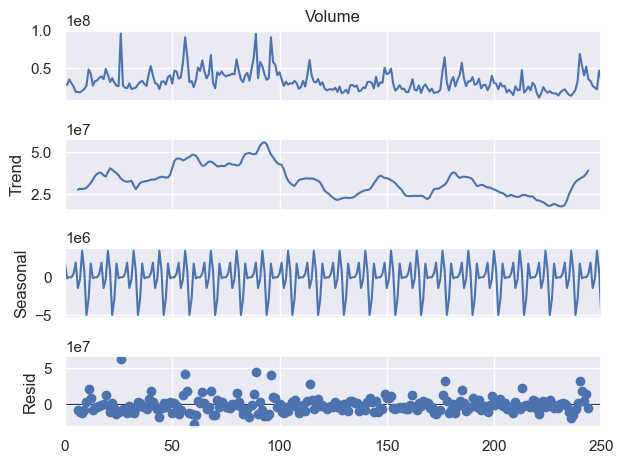

In [34]:
# Decomposition method
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_date['Volume'], period=12)
decomposition.plot()
plt.show()

In [35]:
# Convert Date column
df_date['Date'] = pd.to_datetime(df_date['Date'])

In [36]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        251 non-null    datetime64[ns]
 1   Volume      251 non-null    int64         
 2   Time_Stamp  251 non-null    datetime64[ns]
 3   Open        251 non-null    float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 8.0 KB


## 📈 Data Visualization

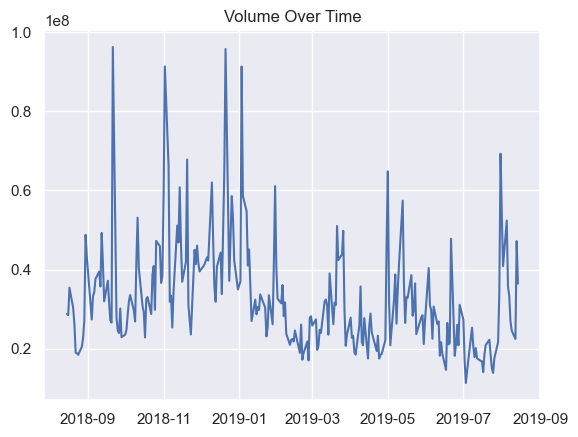

In [38]:
plt.plot(df_date['Date'], df_date['Volume'])
plt.title('Volume Over Time')
plt.show()

In [39]:
df_date['Volume'].describe()

count    2.510000e+02
mean     3.289967e+07
std      1.385336e+07
min      1.136200e+07
25%      2.329740e+07
50%      2.985580e+07
75%      3.927970e+07
max      9.624670e+07
Name: Volume, dtype: float64

## 🧱 Feature Engineering

In [41]:
# Another method of importing dataset
df_final = pd.read_csv('datasets_302666_618181_AAPL.csv', parse_dates=True, index_col=0)
df_final.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-08-15,209.220001,210.740005,208.330002,210.240005,207.027420,28807600
2018-08-16,211.750000,213.809998,211.470001,213.320007,210.060333,28500400
2018-08-17,213.440002,217.949997,213.160004,217.580002,214.255234,35427000
2018-08-20,218.100006,219.179993,215.110001,215.460007,212.167633,30287700
2018-08-21,216.800003,217.190002,214.029999,215.039993,211.754028,26159800


In [42]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2018-08-15 to 2019-08-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       251 non-null    float64
 1   High       251 non-null    float64
 2   Low        251 non-null    float64
 3   Close      251 non-null    float64
 4   Adj Close  251 non-null    float64
 5   Volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB


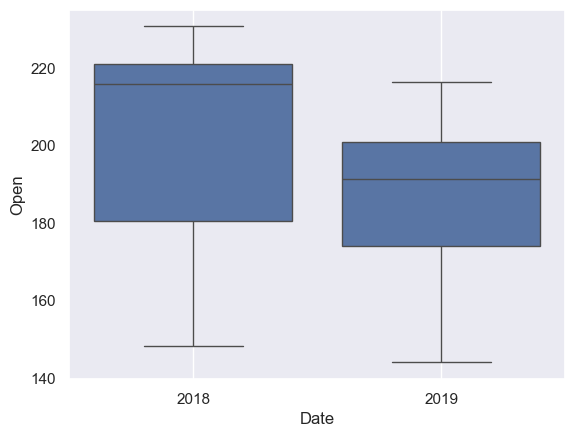

In [43]:
sns.boxplot(x=df_final.index.year, y = df_final['Open'])
plt.grid()
plt.show()

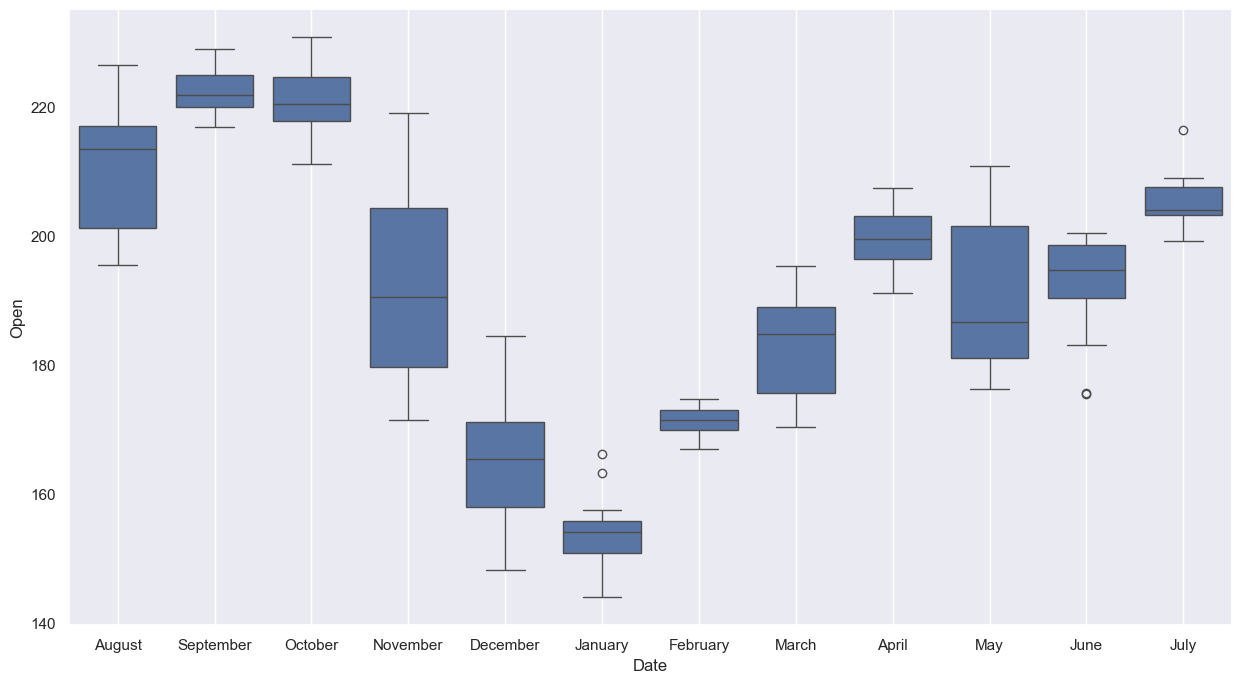

In [44]:
from pylab import rcParams
rcParams['figure.figsize']=15,8
sns.boxplot(x=df_final.index.month_name(), y= df_final['Open'])
plt.grid()
plt.show()

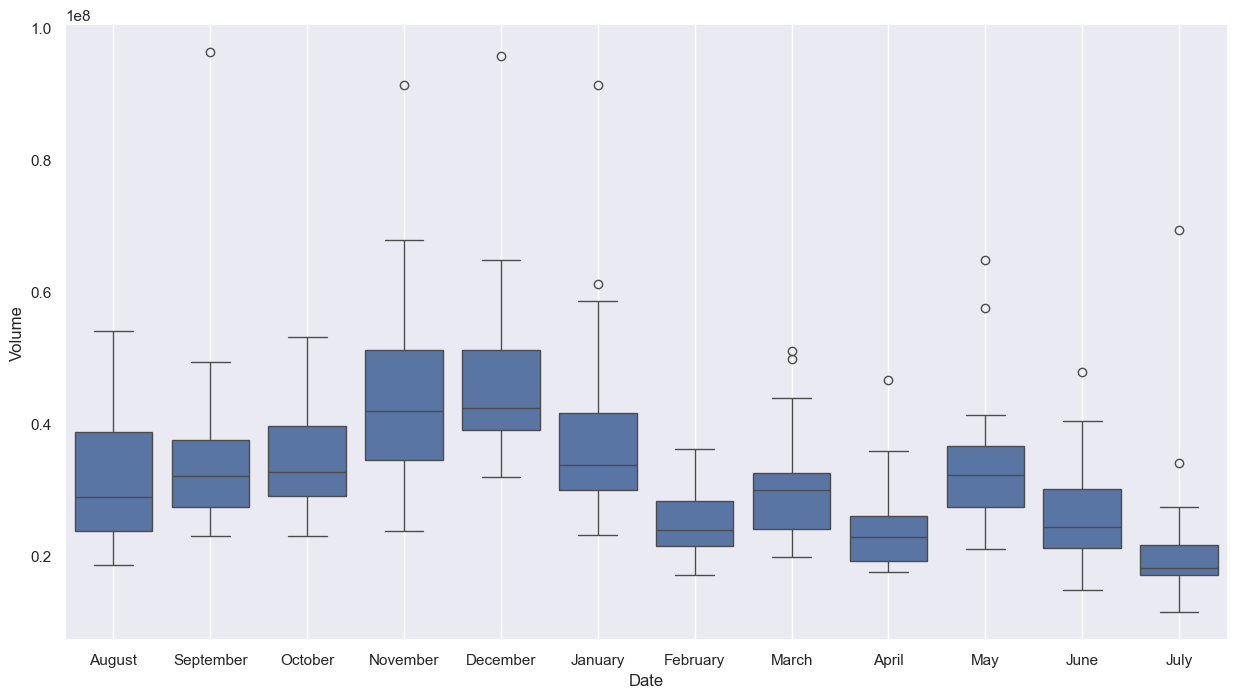

In [45]:
from pylab import rcParams
rcParams['figure.figsize']=15,8
sns.boxplot(x=df_final.index.month_name(), y= df_final['Volume'])
plt.grid()
plt.show()

In [46]:
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year
df_final

,Open,High,Low,Close,Adj Close,Volume,Month,Year
Date,,,,,,,,
2018-08-15,209.220001,210.740005,208.330002,210.240005,207.027420,28807600,8,2018
2018-08-16,211.750000,213.809998,211.470001,213.320007,210.060333,28500400,8,2018
2018-08-17,213.440002,217.949997,213.160004,217.580002,214.255234,35427000,8,2018
2018-08-20,218.100006,219.179993,215.110001,215.460007,212.167633,30287700,8,2018
2018-08-21,216.800003,217.190002,214.029999,215.039993,211.754028,26159800,8,2018
...,...,...,...,...,...,...,...,...
2019-08-08,200.199997,203.529999,199.389999,203.429993,202.659988,27009500,8,2019
2019-08-09,201.300003,202.759995,199.289993,200.990005,200.990005,24619700,8,2019
2019-08-12,199.619995,202.050003,199.149994,200.479996,200.479996,22474900,8,2019


In [47]:
df['Time_Stamp'] = pd.to_datetime(df['Date'])
df_final_model = df.set_index('Time_Stamp')
df_final_model

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
2018-08-15,8/15/2018,209.220001,210.740005,208.330002,210.240005,207.027420,28807600
2018-08-16,8/16/2018,211.750000,213.809998,211.470001,213.320007,210.060333,28500400
2018-08-17,8/17/2018,213.440002,217.949997,213.160004,217.580002,214.255234,35427000
2018-08-20,8/20/2018,218.100006,219.179993,215.110001,215.460007,212.167633,30287700
2018-08-21,8/21/2018,216.800003,217.190002,214.029999,215.039993,211.754028,26159800
...,...,...,...,...,...,...,...
2019-08-08,8/8/2019,200.199997,203.529999,199.389999,203.429993,202.659988,27009500
2019-08-09,8/9/2019,201.300003,202.759995,199.289993,200.990005,200.990005,24619700
2019-08-12,8/12/2019,199.619995,202.050003,199.149994,200.479996,200.479996,22474900


In [48]:
df_final_model['Date'] = pd.to_datetime(df_final_model['Date'])
df_final_model.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2018-08-15 to 2019-08-14
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       251 non-null    datetime64[ns]
 1   Open       251 non-null    float64       
 2   High       251 non-null    float64       
 3   Low        251 non-null    float64       
 4   Close      251 non-null    float64       
 5   Adj Close  251 non-null    float64       
 6   Volume     251 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 15.7 KB


In [49]:
df_final_model.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
2018-08-15,2018-08-15,209.220001,210.740005,208.330002,210.240005,207.027420,28807600
2018-08-16,2018-08-16,211.750000,213.809998,211.470001,213.320007,210.060333,28500400
2018-08-17,2018-08-17,213.440002,217.949997,213.160004,217.580002,214.255234,35427000
2018-08-20,2018-08-20,218.100006,219.179993,215.110001,215.460007,212.167633,30287700
2018-08-21,2018-08-21,216.800003,217.190002,214.029999,215.039993,211.754028,26159800


In [50]:
df_final_model.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
Time_Stamp,,,,,,,
2019-08-08,2019-08-08,200.199997,203.529999,199.389999,203.429993,202.659988,27009500
2019-08-09,2019-08-09,201.300003,202.759995,199.289993,200.990005,200.990005,24619700
2019-08-12,2019-08-12,199.619995,202.050003,199.149994,200.479996,200.479996,22474900
2019-08-13,2019-08-13,201.020004,212.139999,200.479996,208.970001,208.970001,47218500
2019-08-14,2019-08-14,203.160004,206.440002,202.589996,202.750000,202.750000,36453100


In [51]:
len(df_final_model)

251

## 🤖 Time Series Forecasting Using Facebook Prophet

In [53]:
!pip install prophet

In [54]:
import prophet

In [55]:
from prophet import Prophet

In [56]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [57]:
model = Prophet()

In [58]:
df_final_model.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [59]:
df_final_model_1 = df_final_model[['Date','Volume']]
df_final_model_1

,Date,Volume
Time_Stamp,,
2018-08-15,2018-08-15,28807600
2018-08-16,2018-08-16,28500400
2018-08-17,2018-08-17,35427000
2018-08-20,2018-08-20,30287700
2018-08-21,2018-08-21,26159800
...,...,...
2019-08-08,2019-08-08,27009500
2019-08-09,2019-08-09,24619700
2019-08-12,2019-08-12,22474900


In [60]:
df_final_model_1.columns = ['ds','y']

In [61]:
df_final_model_1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2018-08-15 to 2019-08-14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      251 non-null    datetime64[ns]
 1   y       251 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.9 KB


In [62]:
model.fit(df_final_model_1)

00:40:55 - cmdstanpy - INFO - Chain [1] start processing
00:40:56 - cmdstanpy - INFO - Chain [1] done processing


In [63]:
model.component_modes

{'additive': ['weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [64]:
df_final_model_1.tail()

,ds,y
Time_Stamp,,
2019-08-08,2019-08-08,27009500
2019-08-09,2019-08-09,24619700
2019-08-12,2019-08-12,22474900
2019-08-13,2019-08-13,47218500
2019-08-14,2019-08-14,36453100


In [65]:
future_dates = model.make_future_dataframe(periods=1000)
future_dates.tail()

,ds
1246,2022-05-06
1247,2022-05-07
1248,2022-05-08
1249,2022-05-09
1250,2022-05-10


In [66]:
predict = model.predict(future_dates)
predict

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-08-15,3.518019e+07,2.017599e+07,5.207354e+07,3.518019e+07,3.518019e+07,5.774522e+05,5.774522e+05,5.774522e+05,5.774522e+05,5.774522e+05,5.774522e+05,0.0,0.0,0.0,3.575764e+07
1,2018-08-16,3.519278e+07,2.027547e+07,5.284294e+07,3.519278e+07,3.519278e+07,1.107190e+06,1.107190e+06,1.107190e+06,1.107190e+06,1.107190e+06,1.107190e+06,0.0,0.0,0.0,3.629997e+07
2,2018-08-17,3.520538e+07,2.099206e+07,5.429328e+07,3.520538e+07,3.520538e+07,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,0.0,0.0,0.0,3.822372e+07
3,2018-08-20,3.524315e+07,1.990696e+07,5.282560e+07,3.524315e+07,3.524315e+07,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,0.0,0.0,0.0,3.667853e+07
4,2018-08-21,3.525575e+07,1.871124e+07,5.212876e+07,3.525575e+07,3.525575e+07,2.475071e+05,2.475071e+05,2.475071e+05,2.475071e+05,2.475071e+05,2.475071e+05,0.0,0.0,0.0,3.550325e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,2022-05-06,-2.592481e+07,-5.199847e+07,5.678000e+06,-4.859337e+07,-3.184544e+06,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,3.018345e+06,0.0,0.0,0.0,-2.290647e+07
1247,2022-05-07,-2.597456e+07,-5.632714e+07,-1.321915e+05,-4.869617e+07,-3.207526e+06,-3.192934e+06,-3.192934e+06,-3.192934e+06,-3.192934e+06,-3.192934e+06,-3.192934e+06,0.0,0.0,0.0,-2.916749e+07
1248,2022-05-08,-2.602430e+07,-5.786393e+07,-1.160542e+06,-4.877940e+07,-3.226908e+06,-3.192933e+06,-3.192933e+06,-3.192933e+06,-3.192933e+06,-3.192933e+06,-3.192933e+06,0.0,0.0,0.0,-2.921723e+07
1249,2022-05-09,-2.607405e+07,-5.171153e+07,4.741172e+06,-4.886145e+07,-3.228516e+06,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,1.435373e+06,0.0,0.0,0.0,-2.463867e+07


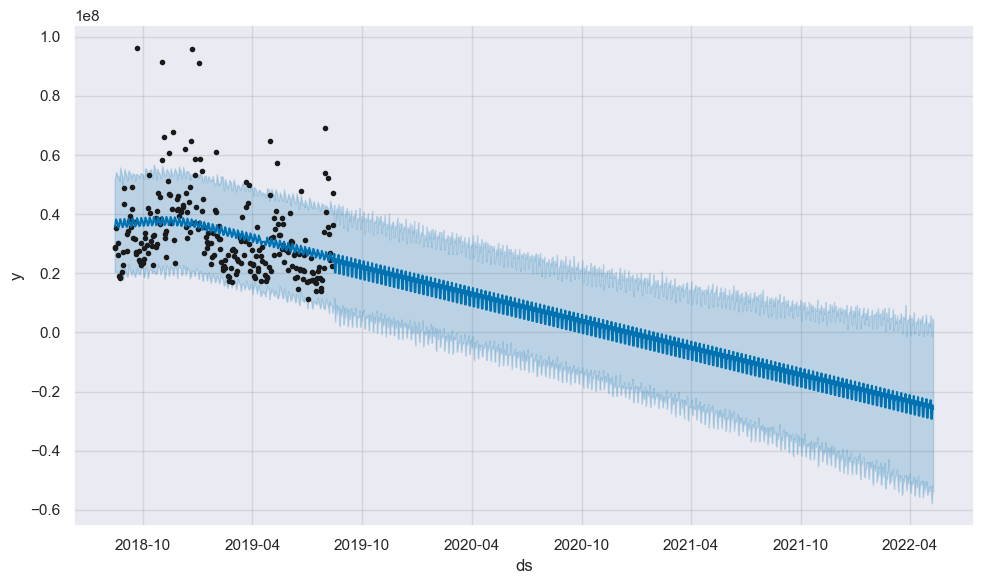

In [67]:
model.plot(predict)

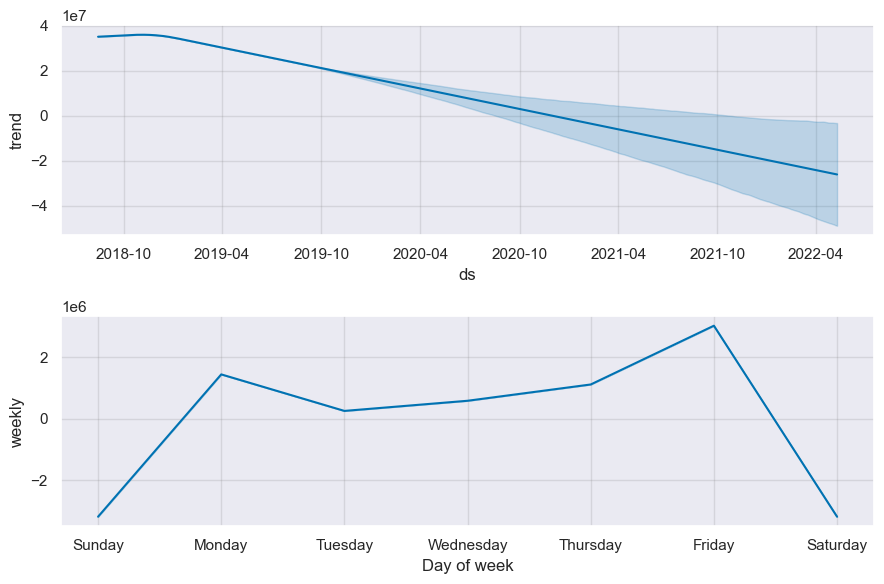

In [68]:
model.plot_components(predict)